In [1]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def sample_q(n: int,
             mus: torch.Tensor,
             covs: torch.Tensor,
             weights: torch.Tensor) -> torch.Tensor:
    """
    Sample n points from a mixture of 2D Gaussians using PyTorch.
    
    Args:
        n: Number of samples to draw.
        mus: Tensor of shape (K, 2) containing the means of each component.
        covs: Tensor of shape (K, 2, 2) containing the covariance matrices.
        weights: 1D tensor of length K with mixture weights (should sum to 1).
    
    Returns:
        samples: Tensor of shape (n, 2) of drawn samples.
    """
    # Draw component indices according to the mixture weights
    comps = torch.multinomial(weights, n, replacement=True)  # (n,)

    # Gather the means and covariances for the chosen components
    chosen_means = mus[comps]       # (n, 2)
    chosen_covs = covs[comps]       # (n, 2, 2)

    # Create a batched multivariate normal distribution
    mvn = torch.distributions.MultivariateNormal(
        loc=chosen_means,
        covariance_matrix=chosen_covs
    )

    # Sample from the batched distribution
    samples = mvn.sample()          # (n, 2)
    return samples

def velocity_field(x: torch.Tensor,
                   t: float,
                   X_ref: torch.Tensor,
                   sigma_min: float,
                   method: str = 'mc') -> torch.Tensor:
    """
    Compute the velocity field u_t(x) at time t given reference samples X_ref.

    Args:
        x: Tensor of shape (B, d) for current particle positions.
        t: float, current time.
        X_ref: Tensor of shape (N, d) for reference sample points.
        sigma_min: float, minimum noise level.
        method: str, one of 'mc', 'gaussian', 'affine', 'gp'.

    Returns:
        Tensor of shape (B, d) giving velocities for each of the B particles.
    """
    B, d = x.shape
    device, dtype = x.device, x.dtype

    if method == 'mc':
        # Monte Carlo approximation of u_t(x)
        denom = 1.0 - (1.0 - sigma_min) * t
        diffs = x.unsqueeze(1) - t * X_ref.unsqueeze(0)       # (B, N, d)
        sq = torch.sum(diffs ** 2, dim=2)                    # (B, N)
        alphas = torch.exp(-0.5 * sq / (denom ** 2))         # (B, N)
        w = alphas / (alphas.sum(dim=1, keepdim=True) + 1e-12)
        x_bar = w @ X_ref                                    # (B, d)
        return (x_bar - (1 - sigma_min) * x) / denom         # (B, d)

    # Estimate Gaussian parameters from samples
    m = X_ref.mean(dim=0)                                   # (d,)
    diff = X_ref - m                                        # (N, d)
    C = diff.T @ diff / (X_ref.size(0) - 1)                 # (d, d)

    if method == 'gaussian':
        # Closed-form Gaussian flow matching (affine form)
        I = torch.eye(d, device=device, dtype=dtype)
        mu_t = t * m                                        # (d,)
        Sigma_t = (1 - (1 - sigma_min) * t)**2 * I + t**2 * C
        dot_mu = m                                          # (d,)
        dot_Sigma = (
            -2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t) * I
            + 2 * t * C
        )                                                   # (d, d)
        Sigma_inv = torch.linalg.inv(Sigma_t)               # (d, d)
        A = 0.5 * dot_Sigma @ Sigma_inv                     # (d, d)
        return dot_mu + (x - mu_t) @ A.T                    # (B, d)

    if method == 'affine':
        # Parametric affine regression: fit u_t(x) = m + A (x - mu_t)
        U_ref = velocity_field(X_ref, t, X_ref, sigma_min, method='mc')  # (N, d)
        mu_t = t * m                                              # (d,)
        X_feat = X_ref - mu_t                                     # (N, d)
        Y_feat = U_ref - m                                        # (N, d)
        A = torch.pinverse(X_feat) @ Y_feat                       # (d, d)
        return m + (x - mu_t) @ A                                 # (B, d)

    if method == 'gp':
        # Adaptive GP regression without manual hyperparams
        # 1) Monte Carlo velocities on reference points
        U_ref = velocity_field(X_ref, t, X_ref, sigma_min, method='mc')  # (N, d)

        # 2) Median heuristic for RBF lengthscale
        N = X_ref.size(0)
        sample = X_ref if N <= 500 else X_ref[torch.randperm(N)[:500]]
        with torch.no_grad():
            pdist = torch.cdist(sample, sample, p=2)
            median_dist = torch.median(pdist[pdist > 0])
            lengthscale = median_dist.clamp(min=1e-3)

        # 3) RBF kernel function
        def rbf_kernel(a: torch.Tensor, b: torch.Tensor, ls: float):
            diff = a.unsqueeze(1) - b.unsqueeze(0)                # (..., N, d)
            dist2 = torch.sum(diff ** 2, dim=-1)                 # (..., N)
            return torch.exp(-0.5 * dist2 / (ls ** 2))

        # 4) Build and solve kernel system via Cholesky
        K = rbf_kernel(X_ref, X_ref, lengthscale)                # (N, N)
        jitter = 1e-6 * K.diag().median()
        K = K + jitter * torch.eye(N, device=device, dtype=dtype)
        L = torch.linalg.cholesky(K)                            # (N, N)
        alpha = torch.cholesky_solve(U_ref, L)                  # (N, d)

        # 5) Predict at new points
        K_star = rbf_kernel(x, X_ref, lengthscale)               # (B, N)
        return K_star @ alpha                                   # (B, d)

    raise ValueError(f"Unsupported method: {method}")


def generate_flow_samples(N_gen: int,
                          L_steps: int,
                          dt: float,
                          X_ref: torch.Tensor,
                          sigma_min: float,
                          method: str = 'mc') -> (torch.Tensor, torch.Tensor):
    """
    Generate N_gen samples by pushing standard normal samples through
    flow‑matching dynamics via Euler integration—fully vectorized.

    Args:
        N_gen: Number of samples to generate.
        L_steps: Number of time steps.
        dt: Time step size.
        X_ref: Tensor of reference samples, shape (N_mc, 2).
        sigma_min: Minimum noise level.

    Returns:
        Z0: Initial samples from N(0, I), shape (N_gen, 2).
        X_gen: Final samples after flow, shape (N_gen, 2).
    """
    # Initialize from standard normal (batch of B = N_gen particles)
    Z0 = torch.randn(N_gen, 2)
    X_gen = Z0.clone()

    # Time‑stepping loop (vectorized velocity evaluation)
    for l in range(L_steps):
        t = l * dt
        # Compute velocity for all particles at once
        u = velocity_field(X_gen, t, X_ref, sigma_min, method)  # (N_gen, 2)
        # Euler update for the whole batch
        X_gen = X_gen + dt * u

    return Z0, X_gen


def visualize_flow(Z0: torch.Tensor,
                   X_gen: torch.Tensor,
                   X_ref: torch.Tensor,
                   colors):
    """
    Visualize initial and final samples colored by nearest reference sample.
    
    Args:
        Z0: Initial samples, tensor of shape (N_gen, 2).
        X_gen: Final samples after flow, tensor of shape (N_gen, 2).
        X_ref: Reference points, tensor of shape (K, 2).
        colors: Array-like of length K with colors for each reference point.
    """
    # Compute distances and find nearest reference index for each final point
    dists = torch.norm(X_gen.unsqueeze(1) - X_ref.unsqueeze(0), dim=2)  # (N_gen, K)
    nearest_idx = dists.argmin(dim=1).cpu().numpy()                     # (N_gen,)

    # Convert tensors to NumPy for plotting
    Z0_np = Z0.cpu().numpy()
    X_gen_np = X_gen.cpu().numpy()
    X_ref_np = X_ref.cpu().numpy()

    # Plot
    plt.figure(figsize=(10, 5))

    # Initial samples
    plt.subplot(1, 2, 1)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(Z0_np[:, 0], Z0_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.5)
    plt.title("Initial Samples by Nearest Target")
    plt.axis('equal')

    # Final samples
    plt.subplot(1, 2, 2)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(X_gen_np[:, 0], X_gen_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.6)
    plt.title("Final Samples by Nearest Target")
    plt.axis('equal')

    plt.tight_layout()
    plt.show()


In [2]:
import torch
import matplotlib.pyplot as plt
import math

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def compute_likelihood(X: torch.Tensor,
                       y: torch.Tensor,
                       H: torch.Tensor,
                       sigma: float) -> torch.Tensor:
    """
    Compute L(x; y) = N(y | Hx, sigma^2 I) at each row of X.

    Args:
        X: tensor of shape (M, 2) (points at which to evaluate)
        y: tensor of shape (k,) (observed vector)
        H: tensor of shape (k, 2) (linear mapping)
        sigma: observation noise std (scalar)

    Returns:
        Tensor of shape (M,) giving likelihood at each X[i].
    """
    # H x for each point
    Hx = X.matmul(H.t())                                           # (M, k)
    diffs = Hx - y.unsqueeze(0)                                    # (M, k)
    exponent = -0.5 * torch.sum(diffs**2, dim=1) / (sigma**2)      # (M,)
    k = H.shape[0]
    const = (1.0 / ((2 * math.pi * sigma**2) ** (k / 2)))
    return const * torch.exp(exponent)                             # (M,)


def compute_mixture_density(X: torch.Tensor,
                            mus: torch.Tensor,
                            covs: torch.Tensor,
                            weights: torch.Tensor) -> torch.Tensor:
    """
    Compute the density of a 2D Gaussian mixture at each row of X.

    Args:
        X: tensor of shape (M, 2) (evaluation points)
        mus: tensor of shape (K, 2) (component means)
        covs: tensor of shape (K, 2, 2) (covariance matrices)
        weights: tensor of length K (mixture weights)

    Returns:
        Tensor of shape (M,) giving mixture density at each X[i].
    """
    M = X.shape[0]
    total = torch.zeros(M, dtype=X.dtype, device=X.device)
    two_pi = 2 * math.pi

    for mu, cov, w in zip(mus, covs, weights):
        inv_cov = torch.inverse(cov)                               # (2,2)
        det_cov = torch.det(cov)                                   # scalar
        norm_const = 1.0 / (two_pi * torch.sqrt(det_cov))
        diff = X - mu.unsqueeze(0)                                 # (M,2)
        exp_term = torch.exp(-0.5 * torch.sum(diff @ inv_cov * diff, dim=1))
        total += w * norm_const * exp_term

    return total                                                   # (M,)


def visualize_heatmap(grid_size: tuple,
                      lims: list,
                      mus: torch.Tensor,
                      covs: torch.Tensor,
                      weights: torch.Tensor,
                      H: torch.Tensor,
                      y_obs: torch.Tensor,
                      sigma_obs: float):
    """
    Plot original density, likelihood, and posterior heatmaps.

    Args:
        grid_size: (nx, ny) number of pixels in x and y
        lims: [(x_min, x_max), (y_min, y_max)]
        mus, covs, weights: mixture parameters (torch tensors)
        H, y_obs, sigma_obs: likelihood parameters
    """
    (x_min, x_max), (y_min, y_max) = lims
    nx, ny = grid_size

    # create grid of points
    xs = torch.linspace(x_min, x_max, nx)
    ys = torch.linspace(y_min, y_max, ny)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')                # (nx,ny)
    pts = torch.stack([Xg.ravel(), Yg.ravel()], dim=1)             # (nx*ny,2)

    # compute values
    rho = compute_mixture_density(pts, mus, covs, weights)        # (nx*ny,)
    L   = compute_likelihood(pts, y_obs, H, sigma_obs)            # (nx*ny,)
    post = rho * L                                                # (nx*ny,)

    # reshape to grid and convert to numpy
    rho_np  = rho.view(ny, nx).cpu().numpy()
    L_np    = L.view(ny, nx).cpu().numpy()
    post_np = post.view(ny, nx).cpu().numpy()

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, data, title in zip(axes,
                               (rho_np, L_np, post_np),
                               ("Original density ρ(x)",
                                "Likelihood L(x; y)",
                                "Unnormalized posterior ρ·L")):
        im = ax.imshow(data,
                       extent=(x_min, x_max, y_min, y_max),
                       origin='lower', aspect='auto')
        ax.set_title(title)
        ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


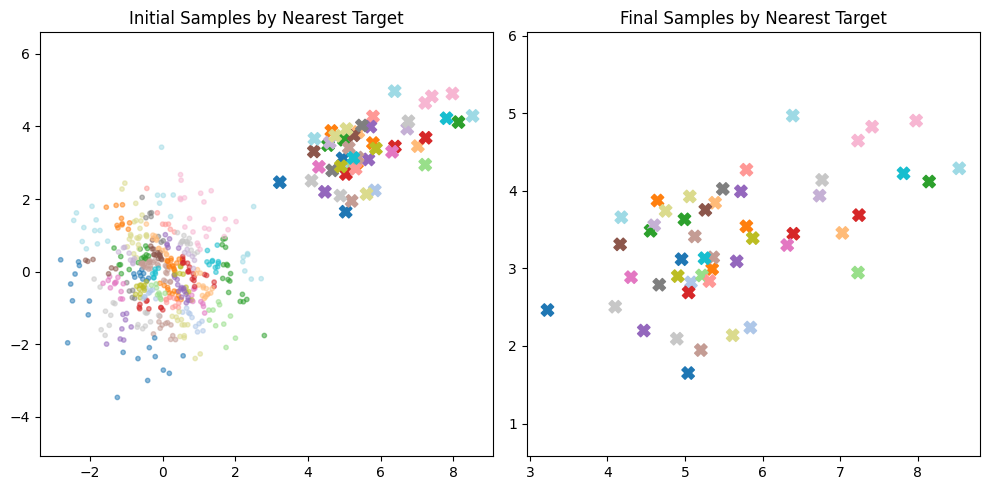

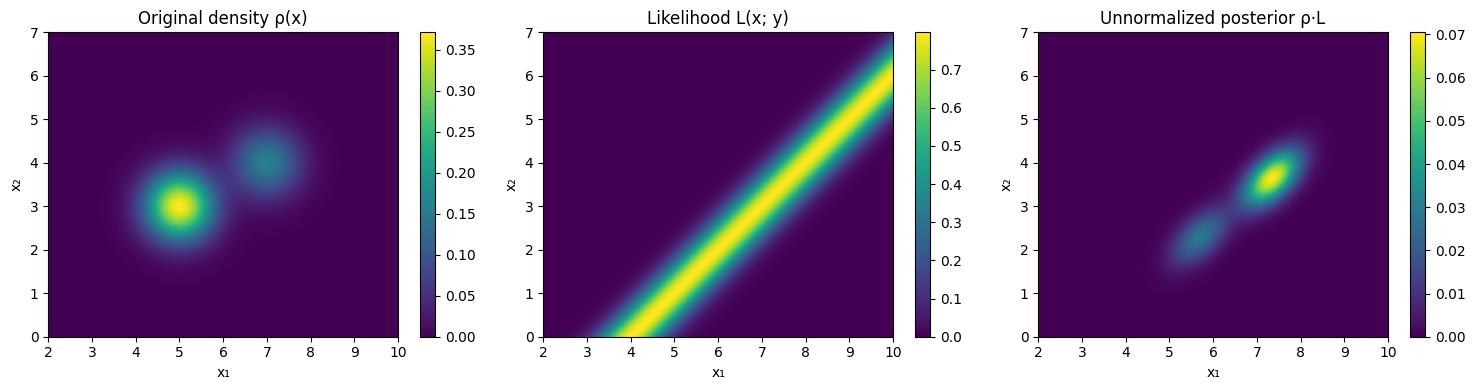

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Main: Parameter Settings and Execution (Torch)
# ----------------------------

# Monte Carlo and generation settings
N_mc      = 50
N_gen     = 500
sigma_min = 1e-3
L_steps   = 100
dt        = 1.0 / L_steps

# target Gaussian mixture parameters (convert to torch tensors)
mus     = torch.tensor([[5.0, 3.0],
                        [7.0, 4.0]], dtype=torch.float32)            # (K=2, 2)
covs    = torch.stack([0.3 * torch.eye(2),
                       0.3 * torch.eye(2)], dim=0)                  # (K=2, 2, 2)
weights = torch.tensor([0.7, 0.3], dtype=torch.float32)               # (K,)

# sample reference targets
X_mc = sample_q(N_mc, mus, covs, weights)                              # (N_mc, 2)

# assign colors for each reference sample (for plotting)
colors = plt.cm.tab20(np.linspace(0, 1, N_mc))

# generate flow-matched samples
Z0, X_gen = generate_flow_samples(N_gen, L_steps, dt, X_mc, sigma_min, method='mc') # both (N_gen, 2)

# visualize the transformation with torch-based functions
visualize_flow(Z0, X_gen, X_mc, colors)

# ----------------------------
# Heatmap Visualization
# ----------------------------
grid_size = (250, 250)            # grid resolution per axis
lims      = [(2, 10), (0, 7)]      # x and y limits

# observation model parameters (as torch tensors)
H         = torch.tensor([[1.0, -1.0]], dtype=torch.float32)          # (1, 2)
y_obs     = torch.tensor([4], dtype=torch.float32)                  # (1,)
sigma_obs = 0.5                                                        # scalar

# plot original density, likelihood, and posterior heatmaps
visualize_heatmap(grid_size, lims,
                  mus, covs, weights,
                  H, y_obs, sigma_obs)


In [34]:
import torch
import torch.nn.functional as F

def mc_guidance(xt, x1_samples, t, sigma_min, J_fn):
    """
    Monte Carlo estimation of the guidance vector field g_t(x) (Algorithm 2).
    
    Parameters:
    -----------
    xt : Tensor of shape [B, D]
        Current states at time t.
    x1_samples : Tensor of shape [N, D]
        i.i.d. samples drawn from the target distribution p(x1).
    t : float or Tensor of shape [B]
        Current time point in [0, 1].
    sigma_min : float
        The σ_min parameter defining the endpoint variance.
    J_fn : callable
        Energy function J(x1): takes a Tensor [N, D] and returns Tensor [N] of energies.
    
    Returns:
    --------
    g : Tensor of shape [B, D]
        The Monte Carlo guidance vector field g_t(x) for each xt.
    """
    B, D = xt.shape
    N, D1 = x1_samples.shape
    assert D == D1, "Dimension mismatch between xt and x1_samples"

    # Ensure t is a tensor of shape [B]
    if not torch.is_tensor(t):
        t = torch.full((B,), t, device=xt.device, dtype=xt.dtype)
    else:
        t = t.to(device=xt.device, dtype=xt.dtype)

    # Compute σ_t according to eq (12): σ_t = 1 - (1 - σ_min) * t
    sigma_t = 1 - (1 - sigma_min) * t             # [B]
    denom   = sigma_t                            # used in the conditional field

    # Expand to [N, B, D] for pairwise computations
    xt_exp = xt.unsqueeze(0).expand(N, B, D)      # [N, B, D]
    x1_exp = x1_samples.unsqueeze(1).expand(N, B, D)
    t_exp  = t.view(1, B, 1)

    # Unnormalized log-weights: α_i = exp(-||xt - t·x1_i||² / (2·σ_t²))
    dist2        = (xt_exp - t_exp * x1_exp).pow(2).sum(-1)  # [N, B]
    inv_two_sig2 = 1.0 / (2 * sigma_t.pow(2))               # [B]
    inv_two_sig2 = inv_two_sig2.view(1, B)
    log_alpha    = -dist2 * inv_two_sig2                    # [N, B]
    weights      = F.softmax(log_alpha, dim=0)              # normalize over samples

    # Estimate Z̃_t = ∑_i w_i · exp(-J(x1_i))
    J_vals   = J_fn(x1_samples)                             # [N]
    exp_negJ = torch.exp(-J_vals).view(N, 1)                # [N, 1]
    Z_tilde  = (weights * exp_negJ).sum(dim=0)               # [B]

    # Conditional vector field u_t(x|x1_i) = (x1_i - (1-σ_min)·xt) / σ_t
    v_cond = (x1_exp - (1 - sigma_min) * xt_exp) / denom.view(1, B, 1)  # [N, B, D]

    # Compute guidance: g = ∑_i w_i · (exp(-J_i)/Z_tilde - 1) · u_t(x|x1_i)
    coeff          = exp_negJ / Z_tilde.view(1, B) - 1.0     # [N, B]
    weighted_coeff = coeff * weights                         # [N, B]
    # g_list = (weighted_coeff.unsqueeze(-1) * v_cond)
    # print(torch.norm(g_list, dim=2).mean(dim=1))
    g = (weighted_coeff.unsqueeze(-1) * v_cond).sum(dim=0)   # [B, D]

    return g


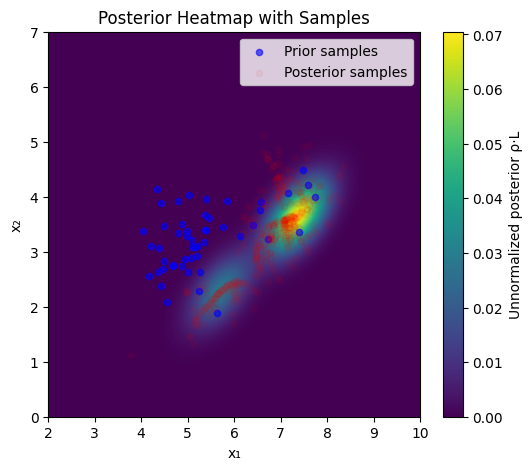

In [38]:
def visualize_posterior(grid_size: tuple,
                        lims: list,
                        mus: torch.Tensor,
                        covs: torch.Tensor,
                        weights: torch.Tensor,
                        H: torch.Tensor,
                        y_obs: torch.Tensor,
                        sigma_obs: float,
                        X_post: torch.Tensor,
                        x1_samples: torch.Tensor):
    """
    Plot the unnormalized posterior heatmap ρ(x)·L(x; y) and overlay posterior samples.

    Args:
        grid_size:     (nx, ny) grid resolution
        lims:          [(x_min, x_max), (y_min, y_max)]
        mus, covs, weights: mixture parameters (torch tensors)
        H, y_obs, sigma_obs: likelihood parameters
        X_post:        Tensor [N_post, 2] of posterior samples to scatter
    """
    (x_min, x_max), (y_min, y_max) = lims
    nx, ny = grid_size

    # create grid of points
    xs = torch.linspace(x_min, x_max, nx)
    ys = torch.linspace(y_min, y_max, ny)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')                # (nx,ny)
    pts = torch.stack([Xg.ravel(), Yg.ravel()], dim=1)             # (nx*ny,2)

    # compute unnormalized posterior = ρ(x) * L(x; y)
    rho  = compute_mixture_density(pts, mus, covs, weights)        # (nx*ny,)
    L    = compute_likelihood(pts, y_obs, H, sigma_obs)            # (nx*ny,)
    post = rho * L                                                # (nx*ny,)

    # reshape to grid
    post_grid = post.view(ny, nx).cpu().numpy()

    # plot posterior heatmap
    plt.figure(figsize=(6, 5))
    plt.imshow(post_grid,
               extent=(x_min, x_max, y_min, y_max),
               origin='lower',
               aspect='auto')
    plt.colorbar(label="Unnormalized posterior ρ·L")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title("Posterior Heatmap with Samples")

    # overlay posterior samples
    Xn = x1_samples[:, 0].cpu().numpy()
    Yn = x1_samples[:, 1].cpu().numpy()
    plt.scatter(Xn, Yn, c='blue', s=20, alpha=0.6, label="Prior samples")
    Xn = X_post[:, 0].cpu().numpy()
    Yn = X_post[:, 1].cpu().numpy()
    plt.scatter(Xn, Yn, c='red', s=20, alpha=0.05, label="Posterior samples")
    plt.legend()
    plt.show()

# ———————————————
# Posterior sampling with MC guidance (flow + guidance)
# ———————————————

# 1. Draw MC target samples once (for guidance)
x1_samples = sample_q(N_mc, mus, covs, weights)    # [N_mc, 2]

# 2. Initialize reference points from the prior
# X_post = sample_q(N_gen, mus, covs, weights)       # [N_gen, 2]
X_post = torch.randn(N_gen, 2)

# 3. Define energy J(x) = - log likelihood
def J_fn(x):
    ll = compute_likelihood(x, y_obs, H, sigma_obs).clamp_min(1e-12) 
    return -torch.log(ll)                                

# 4. Euler integration: base flow v_t + MC guidance g_t
for i in range(L_steps):
    t_i    = i * dt
    v_base = velocity_field(X_post, t_i, x1_samples, sigma_min=1e-3, method='gaussian')
    g      = mc_guidance(X_post, x1_samples, t_i,
                        sigma_min=1e-3, J_fn=J_fn)             # [N_gen, 2]
    X_post = X_post + dt * (v_base + g)

visualize_posterior(grid_size, lims,
                    mus, covs, weights,
                    H, y_obs, sigma_obs,
                    X_post, x1_samples)


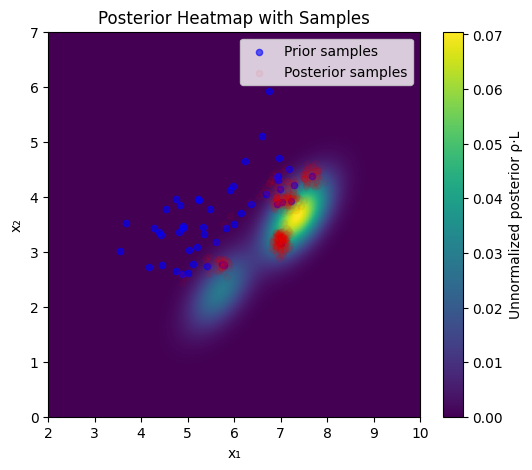

In [43]:
def visualize_posterior(grid_size: tuple,
                        lims: list,
                        mus: torch.Tensor,
                        covs: torch.Tensor,
                        weights: torch.Tensor,
                        H: torch.Tensor,
                        y_obs: torch.Tensor,
                        sigma_obs: float,
                        X_post: torch.Tensor,
                        x1_samples: torch.Tensor):
    """
    Plot the unnormalized posterior heatmap ρ(x)·L(x; y) and overlay posterior samples.

    Args:
        grid_size:     (nx, ny) grid resolution
        lims:          [(x_min, x_max), (y_min, y_max)]
        mus, covs, weights: mixture parameters (torch tensors)
        H, y_obs, sigma_obs: likelihood parameters
        X_post:        Tensor [N_post, 2] of posterior samples to scatter
    """
    (x_min, x_max), (y_min, y_max) = lims
    nx, ny = grid_size

    # create grid of points
    xs = torch.linspace(x_min, x_max, nx)
    ys = torch.linspace(y_min, y_max, ny)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')                # (nx,ny)
    pts = torch.stack([Xg.ravel(), Yg.ravel()], dim=1)             # (nx*ny,2)

    # compute unnormalized posterior = ρ(x) * L(x; y)
    rho  = compute_mixture_density(pts, mus, covs, weights)        # (nx*ny,)
    L    = compute_likelihood(pts, y_obs, H, sigma_obs)            # (nx*ny,)
    post = rho * L                                                # (nx*ny,)

    # reshape to grid
    post_grid = post.view(ny, nx).cpu().numpy()

    # plot posterior heatmap
    plt.figure(figsize=(6, 5))
    plt.imshow(post_grid,
               extent=(x_min, x_max, y_min, y_max),
               origin='lower',
               aspect='auto')
    plt.colorbar(label="Unnormalized posterior ρ·L")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title("Posterior Heatmap with Samples")

    # overlay posterior samples
    Xn = x1_samples[:, 0].cpu().numpy()
    Yn = x1_samples[:, 1].cpu().numpy()
    plt.scatter(Xn, Yn, c='blue', s=20, alpha=0.6, label="Prior samples")
    Xn = X_post[:, 0].cpu().numpy()
    Yn = X_post[:, 1].cpu().numpy()
    plt.scatter(Xn, Yn, c='red', s=20, alpha=0.05, label="Posterior samples")
    plt.legend()
    plt.show()

# ———————————————
# Posterior sampling with MC guidance (flow + guidance)
# ———————————————

# 1. Draw MC target samples once (for guidance)
x1_samples = sample_q(N_mc, mus, covs, weights)    # [N_mc, 2]

# 2. Initialize reference points from the prior
# X_post = sample_q(N_gen, mus, covs, weights)       # [N_gen, 2]
X_post = torch.randn(N_gen, 2)

# 3. Define energy J(x) = - log likelihood
def J_fn(x):
    ll = compute_likelihood(x, y_obs, H, sigma_obs).clamp_min(1e-12) 
    return -torch.log(ll)                                

# 4. Euler integration: base flow v_t + MC guidance g_t
for i in range(L_steps):
    t_i    = i * dt
    v_base = velocity_field(X_post, t_i, x1_samples, sigma_min=1e-1, method='mc')
    g      = mc_guidance(X_post, x1_samples, t_i,
                        sigma_min=1e-3, J_fn=J_fn)             # [N_gen, 2]
    X_post = X_post + dt * (v_base + g)

visualize_posterior(grid_size, lims,
                    mus, covs, weights,
                    H, y_obs, sigma_obs,
                    X_post, x1_samples)


In [32]:
import torch

# compute distance matrix
dist_mat = torch.cdist(X_post, x1_samples)
print(dist_mat.shape)  # e.g. (N, M)

# get the minimum distance for each row: returns (values, indices)
min_vals, _ = torch.min(dist_mat, dim=1)

# now take the maximum over those minima
maxmin_d = torch.max(min_vals)

print("The maximum of the minimal distance between each posterior samples to all prior samples", maxmin_d)


torch.Size([500, 50])
The maximum of the minimal distance between each posterior samples to all prior samples tensor(0.3543)
